### Path Finder: What are the potential paths between two nodes?
### This pipeline can be used to get a ranked path between A and B given a set of paths.

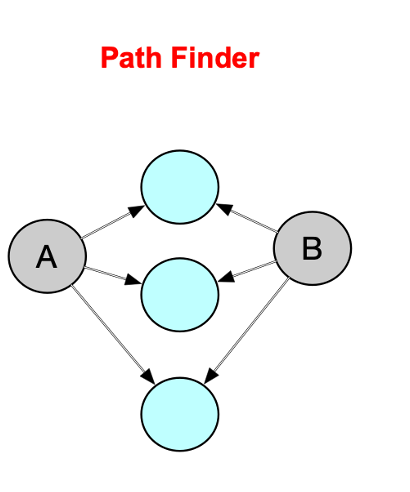


In [1]:
from TCT import TCT

from TCT import name_resolver
from TCT import translator_metakg
from TCT import translator_kpinfo
from TCT import translator_query


import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import requests
import json
import pandas as pd
import  seaborn as sns
import networkx as nx
import numpy as np
import ipycytoscape
import yaml


In [2]:
APInames, metaKG, Translator_KP_info= translator_metakg.load_translator_resources()

All_predicates = list(set(metaKG['Predicate']))
All_categories = list((set(list(set(metaKG['Subject']))+list(set(metaKG['Object'])))))
API_withMetaKG = list(set(metaKG['API']))

    # generate a dictionary of API and its predicates
API_predicates = {}
for api in API_withMetaKG:
    API_predicates[api] = list(set(metaKG[metaKG['API'] == api]['Predicate']))

In [3]:
# select a list of APIs to use and a list of predicates to use
selected_APIlist = []

if len(selected_APIlist) == 0:
    select_APIs = APInames
else:
    select_APIs = {k: APInames[k] for k in selected_APIlist if k in APInames}

selected_metaKG = metaKG[metaKG['API'].isin(select_APIs.keys())]
#print(select_APIs)
print(selected_metaKG.shape)


(22135, 5)


In [4]:
name_resolver.lookup('miR-155', only_taxa='NCBITaxon:9606')

TranslatorNode(curie='NCBIGene:406947', label='MIR155', types=['biolink:Gene', 'biolink:GeneOrGeneProduct', 'biolink:GenomicEntity', 'biolink:ChemicalEntityOrGeneOrGeneProduct', 'biolink:PhysicalEssence', 'biolink:OntologyClass', 'biolink:BiologicalEntity', 'biolink:ThingWithTaxon', 'biolink:NamedThing', 'biolink:Entity', 'biolink:PhysicalEssenceOrOccurrent', 'biolink:MacromolecularMachineMixin'], synonyms=None, curie_synonyms=None)

NCBIGene:3458
MONDO:0100096
CATRAX Pharmacogenomics KP - TRAPI 1.5.0: Success!
Automat-genome-alliance(Trapi v1.5.0): Success!
CATRAX BigGIM DrugResponse Performance Phase KP - TRAPI 1.5.0: Success!
Automat-cam-kp(Trapi v1.5.0): Success!
Automat-hetionet(Trapi v1.5.0): Success!
RTX KG2 - TRAPI 1.5.0: Success!
Automat-robokop(Trapi v1.5.0): Success!
Service Provider TRAPI: Success!
BioThings Explorer (BTE) TRAPI: Success!
CATRAX Pharmacogenomics KP - TRAPI 1.5.0: Success!
Automat-pharos(Trapi v1.5.0): Success!
Automat-robokop(Trapi v1.5.0): Success!
Clinical Trials KP - TRAPI 1.5.0: Success!
Microbiome KP - TRAPI 1.5.0: Success!
RTX KG2 - TRAPI 1.5.0: Success!
Service Provider TRAPI: Success!
BioThings Explorer (BTE) TRAPI: Success!
UniProtKB:P12544-1: no preferred name
ENSEMBL:ENSP00000497585: no preferred name
ENSEMBL:ENSP00000497585: no preferred name
UniProtKB:P12544-1: no preferred name
UniProtKB:Q92614-1: no preferred name
UniProtKB:Q92614-1: no preferred name
NCBIGene:3497: no pr

/home/yzhang/Translator_component_toolkit/TCT/TCT.py:1631: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center", fontsize=fontsize)


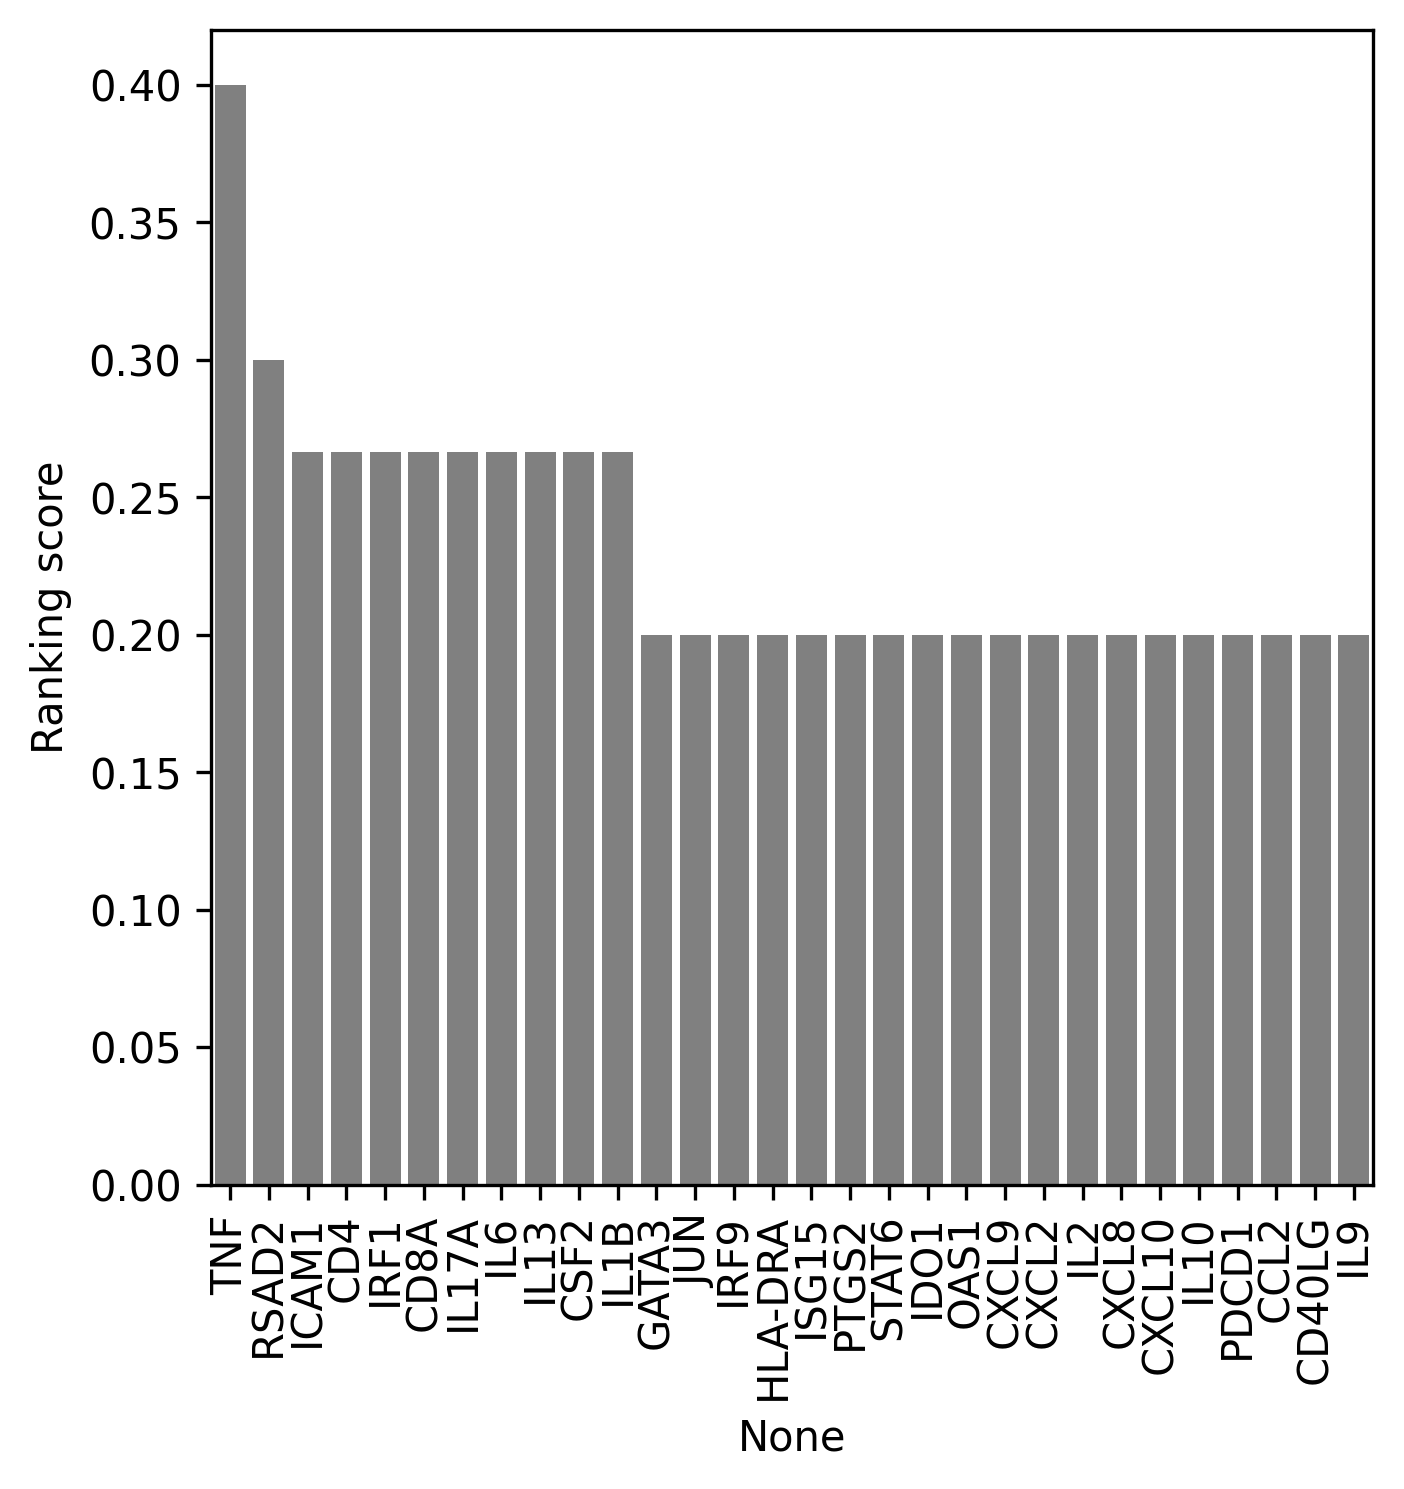

In [5]:
paths, input_node1_id, input_node2_id, result1, result2, result_parsed1, result_parsed2, result_ranked_by_primary_infores1, result_ranked_by_primary_infores2 = TCT.Path_finder(input_node1='NCBIGene:3458', #IFNG
                                                                                                                                                                                input_node2= 'MONDO:0100096', #COVID-19
                                                                                                                                                                                intermediate_categories=['biolink:Protein', 'biolink:Gene' ], 
                                                                                                                                                                                APInames=select_APIs, 
                                                                                                                                                                                metaKG=selected_metaKG, 
                                                                                                                                                                                API_predicates=API_predicates)

In [6]:
intermediate_node = name_resolver.lookup('IDO2', only_taxa='NCBITaxon:9606').curie



In [7]:
matches2 = []
for k in result2.keys():
    if input_node2_id == result2[k]['subject'] and intermediate_node == result2[k]['object']:
        matches2.append(result2[k])
    elif input_node2_id == result2[k]['object'] and intermediate_node == result2[k]['subject']:
        matches2.append(result2[k])

for k in matches2:
    print(k['sources'])

[{'resource_id': 'infores:diseases', 'resource_role': 'primary_knowledge_source'}, {'resource_id': 'infores:rtx-kg2', 'resource_role': 'aggregator_knowledge_source', 'upstream_resource_ids': ['infores:diseases']}]


In [8]:
matches = []
for k in result1.keys():
    if input_node1_id == result1[k]['subject'] and intermediate_node == result1[k]['object']:
        matches.append(result1[k])
    elif input_node1_id == result1[k]['object'] and intermediate_node == result1[k]['subject']:
        matches.append(result1[k])

for k in matches:
    print(k['sources'])

[{'resource_id': 'infores:string', 'resource_role': 'primary_knowledge_source'}, {'resource_id': 'infores:monarchinitiative', 'resource_role': 'aggregator_knowledge_source', 'upstream_resource_ids': ['infores:string']}, {'resource_id': 'infores:service-provider-trapi', 'resource_role': 'aggregator_knowledge_source', 'upstream_resource_ids': ['infores:monarchinitiative']}]
[{'resource_id': 'infores:string', 'resource_role': 'primary_knowledge_source'}, {'resource_id': 'infores:monarchinitiative', 'resource_role': 'aggregator_knowledge_source', 'upstream_resource_ids': ['infores:string']}, {'resource_id': 'infores:biothings-explorer', 'resource_role': 'aggregator_knowledge_source', 'upstream_resource_ids': ['infores:monarchinitiative']}]


In [9]:


# Create a DataFrame from the matches
df = pd.DataFrame(matches)

# Display the DataFrame
df

,predicate,subject,object,attributes,sources
0,biolink:interacts_with,NCBIGene:169355,NCBIGene:3458,[{'attribute_type_id': 'biolink:knowledge_leve...,"[{'resource_id': 'infores:string', 'resource_r..."
1,biolink:interacts_with,NCBIGene:169355,NCBIGene:3458,[{'attribute_type_id': 'biolink:knowledge_leve...,"[{'resource_id': 'infores:string', 'resource_r..."


In [17]:
import lmstudio as lms
model = lms.llm("openai/gpt-oss-120b")
input_text = str(result1) + 'and '+str(result2)
question = "summarize the path that go over NCBIGene:23411 between NCBIGene:2739 and CHEBI:45713" 

In [22]:
result = model.respond("find the path between NPC1 and WNT7B" )

In [23]:
result

PredictionResult(content='<|channel|>analysis<|message|>We need to answer likely about a network of interactions? Provide path maybe gene interaction. Use known pathways: NPC1 interacts with cholesterol transport; WNT7B is ligand in Wnt signaling. Path could be via LDLR, β-catenin etc. Provide plausible molecular path.<|end|><|start|>assistant<|channel|>final<|message|>**Short answer:**  \nA biologically plausible route that connects the lysosomal‑cholesterol transporter **NPC1** to the secreted morphogen **WNT7B** runs through the intracellular cholesterol/oxysterol sensing machinery (SREBP‑2, LXRα/β) → transcriptional regulators of Wnt ligand expression (e.g.,\u202fTCF/LEF, β‑catenin) → a feedback loop that modulates WNT7B secretion.  \n\nBelow is a step‑by‑step “path” that stitches together the best‑supported molecular links from the literature and public interaction databases (STRING, BioGRID, Reactome, Gene Ontology).  Each edge is annotated with the type of evidence (physical bin

In [10]:
paths

,score,output_node,predictes1,predictes2,output_node_name
TNF,0.400000,NCBIGene:7124,biolink:coexpressed_with; biolink:regulates; b...,biolink:genetically_associated_with; biolink:g...,TNF
RSAD2,0.300000,NCBIGene:91543,biolink:coexpressed_with; biolink:affects; bio...,biolink:associated_with; biolink:gene_associat...,RSAD2
ICAM1,0.266667,NCBIGene:3383,biolink:coexpressed_with; biolink:physically_i...,biolink:gene_associated_with_condition; biolin...,ICAM1
CD4,0.266667,NCBIGene:920,biolink:coexpressed_with; biolink:affected_by;...,biolink:genetically_associated_with; biolink:r...,CD4
IRF1,0.266667,NCBIGene:3659,biolink:coexpressed_with; biolink:physically_i...,biolink:gene_associated_with_condition; biolin...,IRF1
...,...,...,...,...,...
IL26,0.033333,NCBIGene:55801,biolink:coexpressed_with,biolink:gene_associated_with_condition,IL26
CLDN5,0.033333,NCBIGene:7122,biolink:coexpressed_with,biolink:gene_associated_with_condition,CLDN5
OXT,0.033333,NCBIGene:5020,biolink:affects; biolink:regulates,biolink:gene_associated_with_condition,OXT
MS4A2,0.033333,NCBIGene:2206,biolink:coexpressed_with,biolink:gene_associated_with_condition,MS4A2


In [11]:
paths

,score,output_node,predictes1,predictes2,output_node_name
TNF,0.400000,NCBIGene:7124,biolink:coexpressed_with; biolink:regulates; b...,biolink:genetically_associated_with; biolink:g...,TNF
RSAD2,0.300000,NCBIGene:91543,biolink:coexpressed_with; biolink:affects; bio...,biolink:associated_with; biolink:gene_associat...,RSAD2
ICAM1,0.266667,NCBIGene:3383,biolink:coexpressed_with; biolink:physically_i...,biolink:gene_associated_with_condition; biolin...,ICAM1
CD4,0.266667,NCBIGene:920,biolink:coexpressed_with; biolink:affected_by;...,biolink:genetically_associated_with; biolink:r...,CD4
IRF1,0.266667,NCBIGene:3659,biolink:coexpressed_with; biolink:physically_i...,biolink:gene_associated_with_condition; biolin...,IRF1
...,...,...,...,...,...
IL26,0.033333,NCBIGene:55801,biolink:coexpressed_with,biolink:gene_associated_with_condition,IL26
CLDN5,0.033333,NCBIGene:7122,biolink:coexpressed_with,biolink:gene_associated_with_condition,CLDN5
OXT,0.033333,NCBIGene:5020,biolink:affects; biolink:regulates,biolink:gene_associated_with_condition,OXT
MS4A2,0.033333,NCBIGene:2206,biolink:coexpressed_with,biolink:gene_associated_with_condition,MS4A2


In [12]:
'NFE2L2' in paths['output_node_name']

True

In [ ]:
forplot = TCT.visulize_path(input_node1_id, name_resolver.lookup('HOXB7', only_taxa='NCBITaxon:9606').curie, input_node2_id, result1, result2) 

CHEBI:83766
NCBIGene:672
CATRAX Pharmacogenomics KP - TRAPI 1.5.0: Success!
Automat-ctd(Trapi v1.5.0): Success!
Automat-pharos(Trapi v1.5.0): Success!
Automat-drug-central(Trapi v1.5.0): Success!
Automat-cam-kp(Trapi v1.5.0): Success!
RTX KG2 - TRAPI 1.5.0: Success!
CATRAX BigGIM DrugResponse Performance Phase KP - TRAPI 1.5.0: Success!
Automat-binding-db(Trapi v1.5.0): Success!
Automat-robokop(Trapi v1.5.0): Success!
Service Provider TRAPI: Success!
BioThings Explorer (BTE) TRAPI: Success!
CATRAX Pharmacogenomics KP - TRAPI 1.5.0: Success!
Automat-genome-alliance(Trapi v1.5.0): Success!
Automat-hetionet(Trapi v1.5.0): Success!
Automat-cam-kp(Trapi v1.5.0): Success!
RTX KG2 - TRAPI 1.5.0: Success!
CATRAX BigGIM DrugResponse Performance Phase KP - TRAPI 1.5.0: Success!
Automat-robokop(Trapi v1.5.0): Success!
Service Provider TRAPI: Success!
BioThings Explorer (BTE) TRAPI: Success!
NodeNorm does not know about these identifiers: NCBIGene:NaN,NCBIGene:8205,TTD.TARGET:T17228,TTD.TARGET:T83

/home/yzhang/Translator_component_toolkit/TCT/TCT.py:1631: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center", fontsize=fontsize)


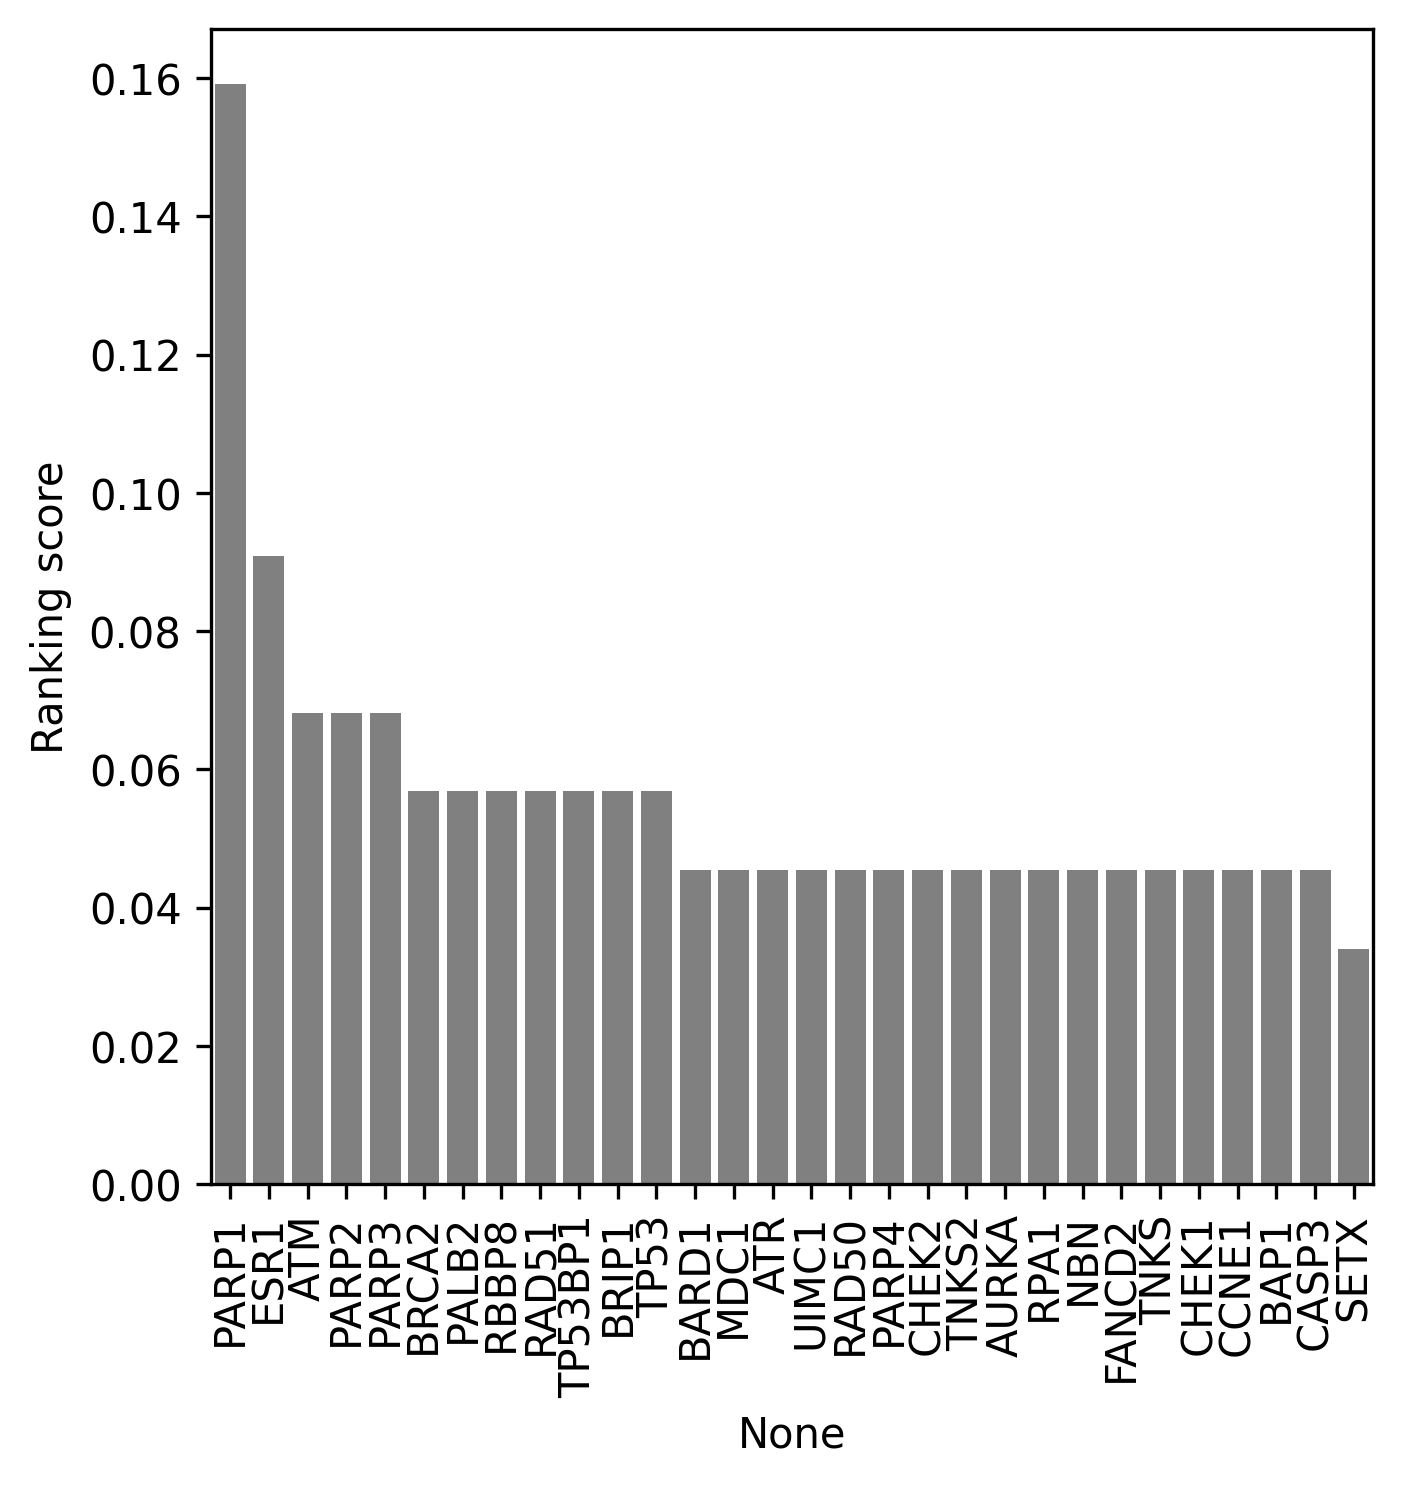

In [15]:
paths, input_node1_id, input_node2_id, result1, result2, result_parsed1, result_parsed2, result_ranked_by_primary_infores1, result_ranked_by_primary_infores2 = TCT.Path_finder('CHEBI:83766', #'Olaparib' 
                                                                                                                                                                                'NCBIGene:672', #'BRCA1' 
                                                                                                                                                                                ['biolink:Gene', 'biolink:Protein'], 
                                                                                                                                                                                APInames=select_APIs, 
                                                                                                                                                                                metaKG=selected_metaKG, 
                                                                                                                                                                                API_predicates=API_predicates)

In [ ]:
forplot = TCT.visulize_path(input_node1_id, name_resolver.lookup('IDO2', only_taxa='NCBITaxon:9606').curie, input_node2_id, result1, result2) 

# link to the UI
https://ui.ci.transltr.io/
